# =========================================================
# CATBOOST MODEL — HDB RESALE PRICE PREDICTION
# =========================================================

In [ ]:
# =========================================================
# 0. IMPORT LIBRARIES
# =========================================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# =========================================================
# STEP 0: DATA EXPLORATION
# =========================================================
file_path = r"../../merged_data/hdb_with_amenities_macro.csv"
df_raw = pd.read_csv(file_path)

df_filtered = df[df["month"] >= "2021-01-01"]

flat_type_counts = df_filtered["flat_type"].value_counts()
print(f"Total records from 2021 Q1 onwards: {len(df_filtered):,}")
print("\nCount by flat type:")
print(flat_type_counts.to_string())

flat_model_counts = df_filtered["flat_model"].value_counts()
print(f"\nTotal records from 2021 Q1 onwards: {len(df_filtered):,}")
print("\nCount by flat model:")
print(flat_model_counts.to_string())

Total records from 2021 Q1 onwards: 134,226

Count by flat type:
flat_type
4 ROOM       57782
5 ROOM       32556
3 ROOM       31844
EXECUTIVE     8885
2 ROOM        3159

Total records from 2021 Q1 onwards: 134,226

Count by flat model:
flat_model
Model A                   50700
Improved                  32227
New Generation            15280
Premium Apartment         14946
Simplified                 4897
Apartment                  4415
Maisonette                 3479
Standard                   3439
DBSS                       2056
Model A2                   1413
2-room                      361
Model A-Maisonette          241
Type S1                     219
Adjoined flat               209
Type S2                     105
Premium Apartment Loft       88
3Gen                         66
Terrace                      61
Improved-Maisonette          15
Premium Maisonette            9


In [ ]:
# =========================================================
# STEP 1: LOAD AND CLEAN DATA
# Match OLS baseline:
# 1. drop nulls
# 2. drop rare flat types
# 3. drop 2020
# 4. log-transform target
# 5. derive num_primary_1km
# =========================================================
file_path = r"../../merged_data/hdb_with_amenities_macro.csv"
df_raw = pd.read_csv(file_path)
print(f"Initial shape: {df_raw.shape}")

df = df_raw.dropna().copy()
print(f"After dropping nulls: {df.shape} (dropped {len(df_raw) - len(df)})")

mask_flat = ~df["flat_type"].isin(["1 ROOM", "MULTI-GENERATION"])
n_before = len(df)
df = df[mask_flat].copy()
print(f"After dropping 1 ROOM and MULTI-GENERATION: {df.shape} (dropped {n_before - len(df)})")

df["year_temp"] = pd.to_datetime(df["month"]).dt.year
n_before = len(df)
df = df[df["year_temp"] != 2020].drop(columns="year_temp").copy()
print(f"After dropping 2020: {df.shape} (dropped {n_before - len(df)})")

# Log-transform target
df["log_resale_price_real"] = np.log(df["resale_price_real"])

# Count of primary schools within 1 km
df["num_primary_1km"] = df["primary_schools_1km"].apply(
    lambda x: len(x.split("|")) if pd.notna(x) and x != "" else 0
)

print(f"num_primary_1km — mean: {df['num_primary_1km'].mean():.2f}, max: {df['num_primary_1km'].max()}")

Initial shape: (157821, 37)
After dropping nulls: (114147, 37) (dropped 43674)
After dropping 1 ROOM and MULTI-GENERATION: (114057, 37) (dropped 90)
After dropping 2020: (96796, 37) (dropped 17261)
num_primary_1km — mean: 2.99, max: 9


In [25]:
# =========================================================
# STEP 2: FEATURE ENGINEERING
# Match OLS baseline:
# - remaining_lease_years
# - floor_category
# - year
# - target = log_resale_price_real
# =========================================================
def parse_remaining_lease(s):
    match = re.match(r"(\d+) years?(?: (\d+) months?)?", str(s))
    if match:
        years = int(match.group(1))
        months = int(match.group(2)) if match.group(2) else 0
        return round(years + months / 12, 2)
    return np.nan

df["remaining_lease_years"] = df["remaining_lease"].apply(parse_remaining_lease)

# Extract lower floor from storey_range
df["floor_lower"] = df["storey_range"].str.extract(r"^(\d+)").astype(int)

df["floor_category"] = pd.cut(
    df["floor_lower"],
    bins=[0, 5, 12, float("inf")],
    labels=["Low", "Mid", "High"],
    right=True
)

# Optional numeric code version if you want to inspect it
floor_map = {"Low": 0, "Mid": 1, "High": 2}
df["floor_category_code"] = df["floor_category"].map(floor_map).astype(int)

# Year for stratification only
df["year"] = pd.to_datetime(df["month"]).dt.year

# Target variable
target = "log_resale_price_real"

print(df[[
    "remaining_lease", "remaining_lease_years",
    "storey_range", "floor_lower", "floor_category",
    "year"
]].head(10))

          remaining_lease  remaining_lease_years storey_range  floor_lower  \
23333   64 years 01 month                  64.08     01 TO 03            1   
23334   64 years 01 month                  64.08     07 TO 09            7   
23335            59 years                  59.00     04 TO 06            4   
23336  58 years 02 months                  58.17     04 TO 06            4   
23337   58 years 01 month                  58.08     01 TO 03            1   
23338  64 years 02 months                  64.17     07 TO 09            7   
23339  58 years 02 months                  58.17     04 TO 06            4   
23340   59 years 01 month                  59.08     04 TO 06            4   
23341            64 years                  64.00     07 TO 09            7   
23342  54 years 04 months                  54.33     04 TO 06            4   

      floor_category  year  
23333            Low  2021  
23334            Mid  2021  
23335            Low  2021  
23336            Low  202

In [26]:
# =========================================================
# STEP 3: STRATIFIED TRAIN/TEST SPLIT (80/20)
# Match OLS baseline exactly for comparability
# =========================================================
df["strat_key"] = (
    df["town"].astype(str) + "_" +
    df["flat_type"].astype(str) + "_" +
    df["year"].astype(str)
)

strat_counts = df["strat_key"].value_counts()
valid_keys = strat_counts[strat_counts >= 2].index
n_before = len(df)
df = df[df["strat_key"].isin(valid_keys)].copy()
print(f"Dropped {n_before - len(df)} rows with singleton strat_key combinations. Remaining: {len(df):,}")

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["strat_key"]
)

print(f"Train size: {len(train_df):,} | Test size: {len(test_df):,}")

print("\nYear distribution (%):")
train_year = train_df["year"].value_counts(normalize=True).sort_index().rename("Train %")
test_year = test_df["year"].value_counts(normalize=True).sort_index().rename("Test %")
year_dist = pd.concat([train_year, test_year], axis=1)
print(year_dist.map(lambda x: f"{x:.2%}"))

print("\nFlat type distribution (%):")
train_flat = train_df["flat_type"].value_counts(normalize=True).rename("Train %")
test_flat = test_df["flat_type"].value_counts(normalize=True).rename("Test %")
flat_dist = pd.concat([train_flat, test_flat], axis=1)
print(flat_dist.map(lambda x: f"{x:.2%}"))

Dropped 7 rows with singleton strat_key combinations. Remaining: 96,789
Train size: 77,431 | Test size: 19,358

Year distribution (%):
     Train %  Test %
year                
2021  21.92%  21.91%
2022  19.92%  19.99%
2023  18.78%  18.77%
2024  20.62%  20.61%
2025  18.76%  18.73%

Flat type distribution (%):
          Train %  Test %
flat_type                
4 ROOM     41.87%  41.89%
3 ROOM     25.56%  25.54%
5 ROOM     23.59%  23.59%
EXECUTIVE   6.75%   6.77%
2 ROOM      2.22%   2.21%


In [27]:
# =========================================================
# STEP 4: PREPARE FEATURES FOR CATBOOST
# Keep feature set aligned with OLS baseline as much as possible
#
# OLS used:
# continuous_features = [
#   remaining_lease_years, nearest_train_dist_m, dist_nearest_hawker_m,
#   dist_nearest_primary_m, num_primary_1km, dist_nearest_park_m,
#   dist_nearest_sportsg_m, dist_nearest_mall_m, dist_nearest_healthcare_m
# ]
# categorical_features = [flat_type, town, floor_category]
#
# Excluded in OLS:
# - floor_area_sqm
# - dist_cbd_m
# =========================================================
feature_cols = [
    "remaining_lease_years",
    "nearest_train_dist_m",
    "dist_nearest_hawker_m",
    "dist_nearest_primary_m",
    "num_primary_1km",
    "dist_nearest_park_m",
    "dist_nearest_sportsg_m",
    "dist_nearest_mall_m",
    "dist_nearest_healthcare_m",
    "flat_type",
    "town",
    "floor_category"
]

categorical_features = ["flat_type", "town", "floor_category"]

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train = train_df[target].copy()
y_test = test_df[target].copy()

# Actual prices retained for evaluation in SGD
y_train_actual = train_df["resale_price_real"].copy()
y_test_actual = test_df["resale_price_real"].copy()

cat_feature_indices = [X_train.columns.get_loc(col) for col in categorical_features]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Categorical feature indices:", cat_feature_indices)
print("Categorical features:", categorical_features)

X_train shape: (77431, 12)
X_test shape: (19358, 12)
Categorical feature indices: [9, 10, 11]
Categorical features: ['flat_type', 'town', 'floor_category']


In [28]:
# =========================================================
# STEP 5: FIT CATBOOST MODEL
# Since this is for fair comparison with OLS, we keep one train/test split.
# We use a validation split inside the training data for early stopping.
# =========================================================
train_sub_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["flat_type"]
)

X_train_sub = train_sub_df[feature_cols].copy()
y_train_sub = train_sub_df[target].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df[target].copy()

cat_feature_indices_sub = [X_train_sub.columns.get_loc(col) for col in categorical_features]

cat_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=3000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=5,
    random_seed=42,
    early_stopping_rounds=100,
    verbose=200
)

cat_model.fit(
    X_train_sub,
    y_train_sub,
    cat_features=cat_feature_indices_sub,
    eval_set=(X_val, y_val),
    use_best_model=True
)

print("Best iteration:", cat_model.get_best_iteration())
print("Best validation score:", cat_model.get_best_score())

0:	learn: 0.3057228	test: 0.3066553	best: 0.3066553 (0)	total: 66.8ms	remaining: 3m 20s
200:	learn: 0.0798735	test: 0.0827976	best: 0.0827976 (200)	total: 15.1s	remaining: 3m 30s
400:	learn: 0.0681976	test: 0.0714811	best: 0.0714811 (400)	total: 30.5s	remaining: 3m 17s
600:	learn: 0.0630686	test: 0.0666461	best: 0.0666461 (600)	total: 45.7s	remaining: 3m 2s
800:	learn: 0.0601589	test: 0.0642088	best: 0.0642088 (800)	total: 1m 1s	remaining: 2m 48s
1000:	learn: 0.0582359	test: 0.0626485	best: 0.0626485 (1000)	total: 1m 16s	remaining: 2m 32s
1200:	learn: 0.0567385	test: 0.0615713	best: 0.0615713 (1200)	total: 1m 32s	remaining: 2m 18s
1400:	learn: 0.0555743	test: 0.0608132	best: 0.0608132 (1400)	total: 1m 48s	remaining: 2m 3s
1600:	learn: 0.0546211	test: 0.0602191	best: 0.0602191 (1600)	total: 2m 3s	remaining: 1m 48s
1800:	learn: 0.0538290	test: 0.0597760	best: 0.0597760 (1800)	total: 2m 19s	remaining: 1m 32s
2000:	learn: 0.0531334	test: 0.0594105	best: 0.0594105 (2000)	total: 2m 35s	remai

In [29]:
# =========================================================
# STEP 6: GENERATE PREDICTIONS
# Predictions made in log space, then converted back to SGD
# =========================================================
y_test_pred_log = cat_model.predict(X_test)
y_test_pred = np.exp(y_test_pred_log)

# Optional: train predictions
y_train_pred_log = cat_model.predict(X_train)
y_train_pred = np.exp(y_train_pred_log)

In [30]:
# =========================================================
# STEP 7: EVALUATION
# Match OLS metrics:
# - RMSE
# - asymmetric Lin-Lin loss
# - 80% interval coverage (using conformal interval instead of OLS formula)
# =========================================================
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))

def linlin_loss(y_true, y_pred, underpredict_weight=2.0):
    """
    Asymmetric linear loss penalising underprediction more heavily than overprediction.
    underpredict_weight=2.0 means predicted < actual is penalised at 2x.
    Overprediction is penalised at 1x.
    """
    errors = np.array(y_true) - np.array(y_pred)  # positive = underprediction
    loss = np.where(errors > 0, underpredict_weight * errors, -errors)
    return np.mean(loss)

test_rmse = rmse(y_test_actual, y_test_pred)
test_linlin = linlin_loss(y_test_actual, y_test_pred, underpredict_weight=2.0)
test_r2 = r2_score(y_test_actual, y_test_pred)

print("=== CATBOOST MODEL EVALUATION ===")
print(f"RMSE:          ${test_rmse:,.0f}")
print(f"R²:            {test_r2:.3f}")
print(f"Linlin Loss:   ${test_linlin:,.0f} (underpredict weight = 2.0)")

=== CATBOOST MODEL EVALUATION ===
RMSE:          $41,236
R²:            0.963
Linlin Loss:   $43,361 (underpredict weight = 2.0)


In [31]:
# =========================================================
# STEP 8: 80% PREDICTION INTERVALS VIA CONFORMAL CALIBRATION
# OLS used built-in prediction intervals.
# For CatBoost, a clean comparison is conformal intervals.
# =========================================================
y_val_actual = val_df["resale_price_real"].copy()
y_val_pred_log = cat_model.predict(X_val)
y_val_pred = np.exp(y_val_pred_log)

# 80% interval => alpha = 0.2
alpha = 0.2
val_abs_errors = np.abs(y_val_actual - y_val_pred)
q = np.quantile(val_abs_errors, 1 - alpha)

pi_lower = y_test_pred - q
pi_upper = y_test_pred + q

coverage = ((y_test_actual.values >= pi_lower) & (y_test_actual.values <= pi_upper)).mean()

print(f"\n80% Prediction Interval Coverage: {coverage:.1%}")
if coverage < 0.70:
    print("WARNING: Coverage < 70%. Prediction intervals are too narrow — model may be overconfident.")
elif coverage > 0.90:
    print("WARNING: Coverage > 90%. Prediction intervals are too wide — model may be underconfident.")
else:
    print("Coverage within expected range (70%–90%).")


80% Prediction Interval Coverage: 80.1%
Coverage within expected range (70%–90%).



Feature importance:
                  feature  importance
                flat_type   39.461490
                     town   17.929269
    remaining_lease_years   17.650860
    dist_nearest_hawker_m    5.689295
     nearest_train_dist_m    3.526243
          num_primary_1km    3.188059
           floor_category    2.842264
      dist_nearest_mall_m    2.483821
   dist_nearest_sportsg_m    2.467172
dist_nearest_healthcare_m    2.362213
      dist_nearest_park_m    1.472197
   dist_nearest_primary_m    0.927117


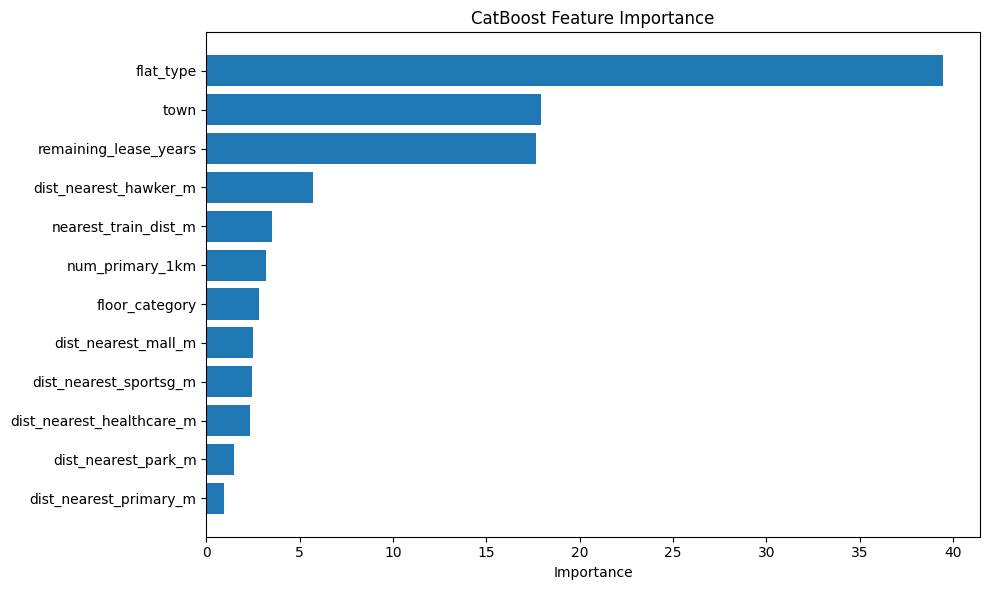

In [32]:
# =========================================================
# STEP 9: FEATURE IMPORTANCE
# =========================================================
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": cat_model.get_feature_importance()
}).sort_values("importance", ascending=False)

print("\nFeature importance:")
print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("CatBoost Feature Importance")
plt.tight_layout()
plt.show()

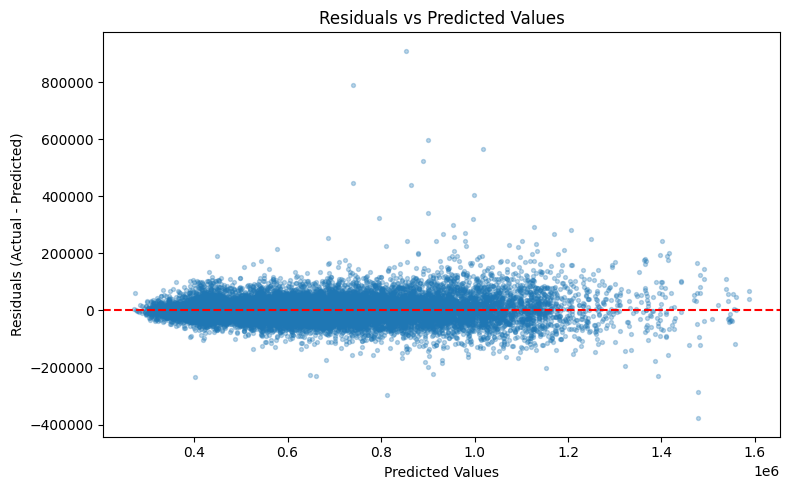

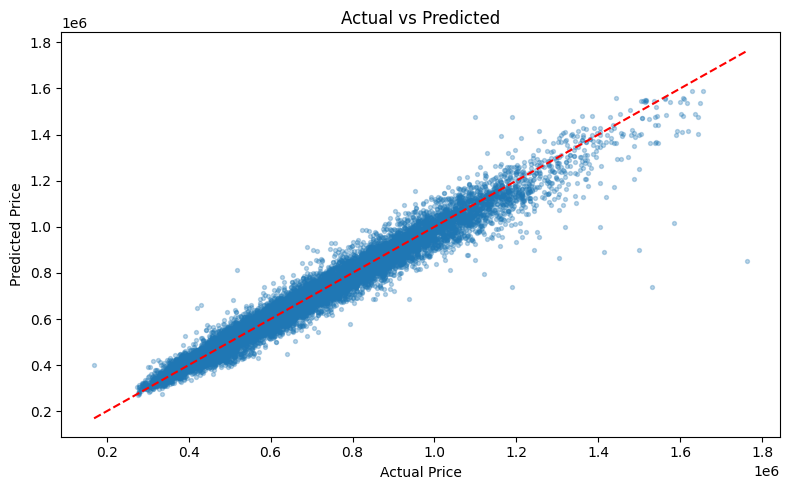


Mean residual by town (sorted):
town
SEMBAWANG          -3893.882120
CENTRAL AREA       -1564.453335
BUKIT BATOK        -1377.607453
BEDOK                161.640023
YISHUN               242.923364
BUKIT PANJANG        408.046935
SERANGOON            573.877743
HOUGANG             1017.837410
TAMPINES            1090.766236
JURONG WEST         1210.593044
SENGKANG            1873.095872
PUNGGOL             2321.623939
CHOA CHU KANG       2355.144176
PASIR RIS           2469.368044
WOODLANDS           2614.298017
ANG MO KIO          2836.132427
TOA PAYOH           3403.217955
CLEMENTI            3704.661337
BUKIT MERAH         4058.998997
JURONG EAST         4303.790563
QUEENSTOWN          5017.469835
MARINE PARADE       5289.142838
KALLANG/WHAMPOA     6190.599209
BISHAN             11792.778225
BUKIT TIMAH        12506.035070
GEYLANG            19145.956858

Mean residual by flat_type (sorted):
flat_type
2 ROOM       -187.714501
4 ROOM       1753.619861
3 ROOM       2145.724480
5 ROOM 

In [33]:
# =========================================================
# STEP 10: DIAGNOSTICS
# =========================================================
residuals_actual = y_test_actual - y_test_pred

# Residuals vs predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals_actual, alpha=0.3, s=8)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted Values")
plt.tight_layout()
plt.show()

# Actual vs predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test_actual, y_test_pred, alpha=0.3, s=8)
min_val = min(y_test_actual.min(), y_test_pred.min())
max_val = max(y_test_actual.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.show()

# Residuals by town and flat type
resid_df = pd.DataFrame({
    "town": test_df["town"].values,
    "flat_type": test_df["flat_type"].values,
    "residual": residuals_actual.values
})

print("\nMean residual by town (sorted):")
town_resid = resid_df.groupby("town")["residual"].mean().sort_values()
print(town_resid.to_string())

flagged_towns = town_resid[town_resid.abs() > 30000]
if len(flagged_towns) > 0:
    print("\nWARNING: Towns with |mean residual| > $30,000:")
    print(flagged_towns.to_string())

print("\nMean residual by flat_type (sorted):")
flat_resid = resid_df.groupby("flat_type")["residual"].mean().sort_values()
print(flat_resid.to_string())

flagged_flats = flat_resid[flat_resid.abs() > 30000]
if len(flagged_flats) > 0:
    print("\nWARNING: Flat types with |mean residual| > $30,000:")
    print(flagged_flats.to_string())